# Best cases for all Ye & Ghassemi fracture samples

This notebook creates an AGU/JGR: Solid Earth-style version of the Ye & Ghassemi Figure-7 layout for SW-T1, SW-T2, SW-S3, and SW-S4. Each sample retains three stacked hydromechanical plots and the Stage 1–3 annotations.

Solid colored curves are the selected numerical result. The digitized Ye & Ghassemi (2018) validation histories are shown only as open points, using the same color as their matching numerical curve. The selected case names are entered manually below.

In [1]:
%matplotlib inline

from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Locate the ORCA project whether Jupyter starts here or in a parent folder."""
    for candidate in (start, *start.parents):
        if (candidate / 'scripts' / 'plot_best_cases_figure7.py').is_file():
            return candidate
    raise FileNotFoundError('Could not locate scripts/plot_best_cases_figure7.py')


PROJECT_ROOT = find_project_root()
SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'plot_best_cases_figure7.py'

spec = importlib.util.spec_from_file_location('best_cases_figure7', SCRIPT_PATH)
plotting = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = plotting
spec.loader.exec_module(plotting)

print(f'Project root: {PROJECT_ROOT}')

Project root: /media/geomechanics/Data4TB/projects/orca_4.0


## Configuration

Enter the case names by hand here. These defaults are the strict numerical rank-one cases. SW-S4 had a rank-one tie, so the authoritative validation case `93_07` is used.

In [2]:
SELECTED_CASES = {
    'SWT1': '99_01_swt1_vm50um_ppfix',
    'SWT2': '100_04_swt2_apscale0p0177_ppfix',
    'SWS3': '92_03_sw3_final_paperjrc_resc1p40',
    'SWS4': '93_07_sw4_final_theta30_jrc5_ppfix',
}

OUTPUT_DIR = PROJECT_ROOT / 'doc' / 'independent_analysis' / 'figures'
DPI = 400

## Resolve and verify the selected cases

This cell requires every manually entered case to occur exactly once in the ranking CSV. It then shows the case, rank, error, and selection status before plotting.

In [3]:
ranking = pd.read_csv(plotting.RANKING_PATH)
selected = plotting.select_best_cases(ranking, SELECTED_CASES)
selection_table = pd.DataFrame([
    {
        'sample': sample,
        'case': selected[sample]['case'],
        'rank': int(selected[sample]['rank_within_sample']),
        'mean_nRMSE_pct': float(selected[sample]['mean_nrmse_pct']),
        'selection_status': selected[sample]['selection_status'],
    }
    for sample in plotting.SAMPLE_ORDER
])
display(selection_table.style.format({'mean_nRMSE_pct': '{:.3f}'}))

,sample,case,rank,mean_nRMSE_pct,selection_status
0,SWT1,99_01_swt1_vm50um_ppfix,1,3.679,targeted_calibration_probe
1,SWT2,100_04_swt2_apscale0p0177_ppfix,1,2.132,targeted_calibration_probe
2,SWS3,92_03_sw3_final_paperjrc_resc1p40,1,3.582,historical_calibration
3,SWS4,93_07_sw4_final_theta30_jrc5_ppfix,1,6.139,authoritative_validation


## Figure-7 layout with validation overlays

Every available validation channel is drawn on the corresponding colored axis. Piston and production-pressure validation points appear only for samples where those digitized histories are available.

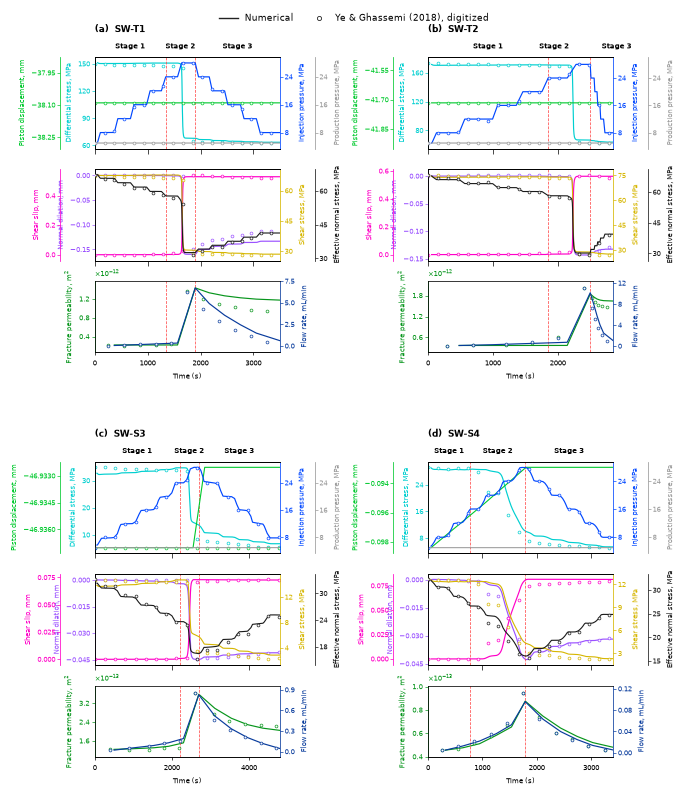

In [4]:
figure, selected = plotting.build_figure(ranking, SELECTED_CASES)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = OUTPUT_DIR / 'YE2018_BEST_CASES_HYDROMECHANICAL.pdf'
png_path = OUTPUT_DIR / 'YE2018_BEST_CASES_HYDROMECHANICAL.png'
figure.savefig(pdf_path, bbox_inches='tight')
figure.savefig(png_path, dpi=DPI, bbox_inches='tight')
plt.show()

## Saved publication files

In [5]:
print(f'PDF: {pdf_path}')
print(f'PNG: {png_path}')

PDF: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_HYDROMECHANICAL.pdf
PNG: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_HYDROMECHANICAL.png


## Table 2 hold-stage comparisons

The same manually selected cases are evaluated at the 11 loading/unloading holds reported in Ye & Ghassemi (2018), Table 2. Numerical results are solid curves; Table 2 observations are same-colored open points without connecting lines. The mechanical and hydraulic quantities are separated into two AGU-width pages for legibility. Numerical normal dilation and shear slip use the first hold as their zero datum, consistent with the comparison/ranking workflow.

In [6]:
TABLE2_SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'plot_best_cases_table2_agu.py'
table2_spec = importlib.util.spec_from_file_location(
    'best_cases_table2_agu', TABLE2_SCRIPT_PATH
)
table2_plotting = importlib.util.module_from_spec(table2_spec)
sys.modules[table2_spec.name] = table2_plotting
table2_spec.loader.exec_module(table2_plotting)

,sample,case,rank,mean_nRMSE_pct,selection_status
0,SWT1,99_01_swt1_vm50um_ppfix,1,3.679,targeted_calibration_probe
1,SWT2,100_04_swt2_apscale0p0177_ppfix,1,2.132,targeted_calibration_probe
2,SWS3,92_03_sw3_final_paperjrc_resc1p40,1,3.582,historical_calibration
3,SWS4,93_07_sw4_final_theta30_jrc5_ppfix,1,6.139,authoritative_validation


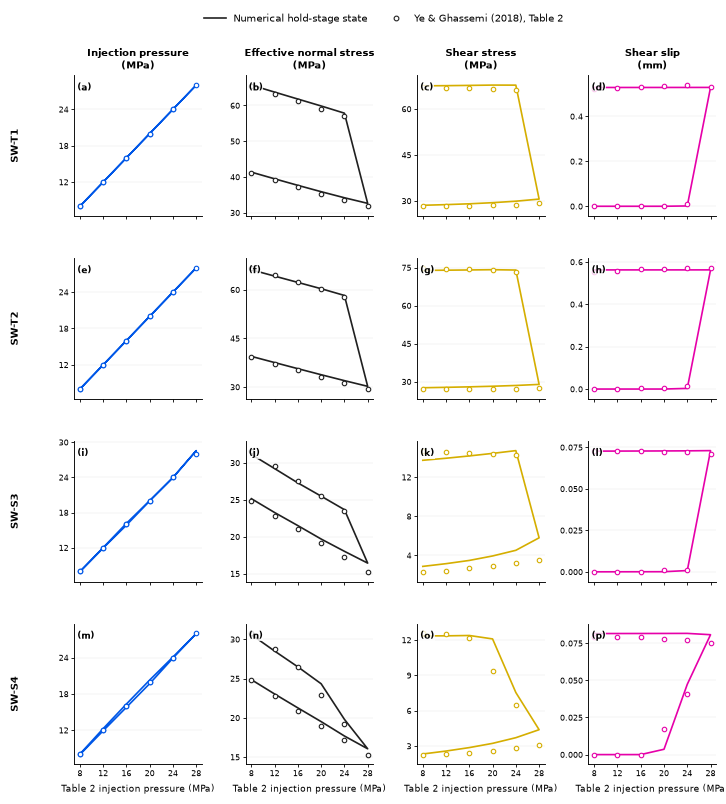

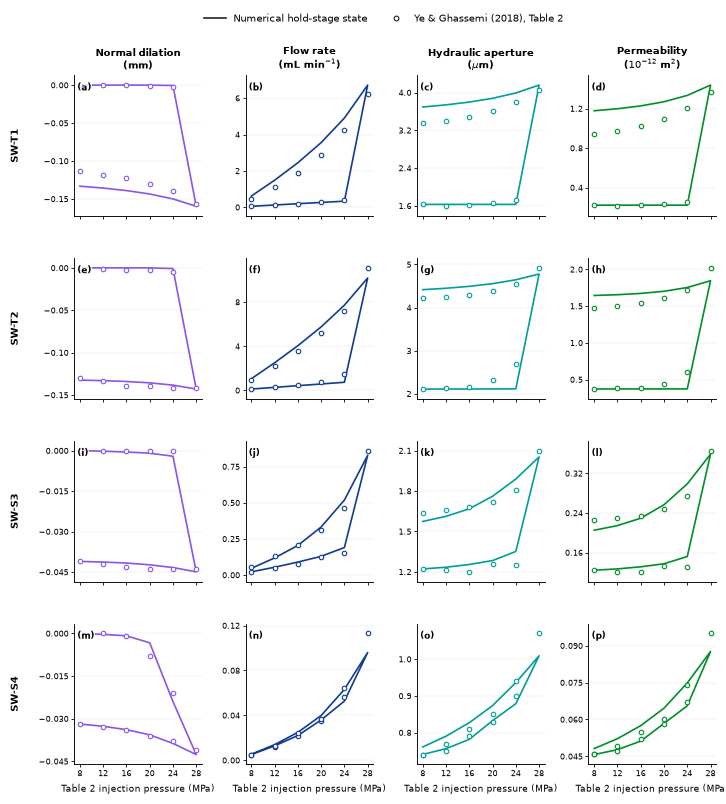

In [7]:
table2_figures, table2_selection, table2_comparison = table2_plotting.build_figures(
    SELECTED_CASES
)
table2_paths = table2_plotting.save_outputs(
    table2_figures, table2_comparison, OUTPUT_DIR, dpi=DPI
)
display(table2_selection.style.format({'mean_nRMSE_pct': '{:.3f}'}))
plt.show()

In [8]:
for output_name, output_path in table2_paths.items():
    print(f'{output_name}: {output_path}')

display(table2_comparison.head(12))

combined_pdf: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_TABLE2_AGU.pdf
mechanical_pdf: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_TABLE2_MECHANICAL_AGU.pdf
hydraulic_pdf: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_TABLE2_HYDRAULIC_AGU.pdf
mechanical_png: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_TABLE2_MECHANICAL_AGU.png
hydraulic_png: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_TABLE2_HYDRAULIC_AGU.png
comparison_csv: /media/geomechanics/Data4TB/projects/orca_4.0/doc/independent_analysis/figures/YE2018_BEST_CASES_TABLE2_COMPARISON.csv


,sample,stage,segment,injection_pressure_MPa,quantity,numerical,table2,numerical_minus_table2
0,SWT1,1,loading,8,Q_ml_min,0.052794,0.053,-0.000206
1,SWT1,1,loading,8,sigma_n_MPa,65.708916,65.470,0.238916
2,SWT1,1,loading,8,tau_MPa,67.548386,67.160,0.388386
3,SWT1,1,loading,8,dn_mm,0.000000,0.000,0.000000
4,SWT1,1,loading,8,ds_mm,0.000000,0.000,0.000000
5,SWT1,1,loading,8,ah_um,1.630000,1.630,0.000000
6,SWT1,1,loading,8,k_1e12_m2,0.221408,0.220,0.001408
7,SWT1,2,loading,12,Q_ml_min,0.123186,0.114,0.009186
8,SWT1,2,loading,12,sigma_n_MPa,63.742936,63.350,0.392936
9,SWT1,2,loading,12,tau_MPa,67.602828,66.960,0.642828


### Reporting note

The default SW-S3 selection (`92_03`) is the strict numerical rank-one result but is marked as a historical calibration case in the ranking notes. To use the preferred authoritative reporting case, replace it in `SELECTED_CASES` with `93_05_sw3_final_paperjrc_resc1p40` and rerun the notebook.